In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

In [ ]:
reviews = pd.read_csv("/content/drive/MyDrive/P1/dataset_olist/olist_order_reviews_dataset.csv")
orders = pd.read_csv("/content/drive/MyDrive/P1/dataset_olist/olist_orders_dataset.csv")
items = pd.read_csv("/content/drive/MyDrive/P1/dataset_olist/olist_order_items_dataset.csv")

In [ ]:
# Merge reviews with orders
df = pd.merge(reviews, orders, on="order_id", how="inner")

# Convert dates
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Compute delivery delay in days
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['delivery_delay'] = df['delivery_delay'].fillna(0)  # handle NaN (not delivered)


In [ ]:
def assign_ces(row):
    delay = row['delivery_delay']
    score = row['review_score']

    if (delay <= 0) and (score >= 4):
        return 1   # Easy
    elif (delay <= 7) and (score == 3):
        return 2   # Neutral
    else:
        return 3   # Difficult

df['ces_label'] = df.apply(assign_ces, axis=1)


In [ ]:
ces_df = df[['review_comment_message', 'ces_label']].dropna()

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    ces_df['review_comment_message'].tolist(),
    ces_df['ces_label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
class CESDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx] - 1)  # shift to 0,1,2
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CESDataset(train_encodings, train_labels)
test_dataset = CESDataset(test_encodings, test_labels)

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)


/tmp/ipython-input-4135352462.py:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.459600,0.471132
2,0.396100,0.458109
3,0.366100,0.467515


TrainOutput(global_step=6147, training_loss=0.42956407868767127, metrics={'train_runtime': 2446.691, 'train_samples_per_second': 40.194, 'train_steps_per_second': 2.512, 'total_flos': 6468840709906176.0, 'train_loss': 0.42956407868767127, 'epoch': 3.0})

In [ ]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = np.array(test_labels) - 1

print(classification_report(y_true, y_pred, target_names=["Easy", "Neutral", "Difficult"]))


              precision    recall  f1-score   support

        Easy       0.90      0.94      0.92      5183
     Neutral       0.30      0.14      0.19       705
   Difficult       0.80      0.84      0.82      2308

    accuracy                           0.84      8196
   macro avg       0.66      0.64      0.64      8196
weighted avg       0.82      0.84      0.83      8196



In [ ]:
output_dir = "/content/drive/MyDrive/P1/ces_model/"

trainer.save_model(output_dir)        # saves model, config, optimizer state
tokenizer.save_pretrained(output_dir) # saves tokenizer

print("✅ Model saved at:", output_dir)

✅ Model saved at: /content/drive/MyDrive/P1/ces_model/


In [ ]:
# --- CES Model: Weighted Trainer Version ---
# Improves class imbalance using class weights
# Model: bert-base-multilingual-cased
# Uses weighted loss to improve Neutral class detection


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
import torch
import numpy as np
from sklearn.metrics import classification_report

In [ ]:
import pandas as pd

reviews = pd.read_csv("/content/drive/MyDrive/P1/dataset_olist/olist_order_reviews_dataset.csv")
orders  = pd.read_csv("/content/drive/MyDrive/P1/dataset_olist/olist_orders_dataset.csv")

# Merge on order_id to get delivery dates
df = pd.merge(reviews, orders, on="order_id", how="inner")

# keep only required columns and drop rows with missing text
df = df[['review_comment_message', 'review_score',
         'order_delivered_customer_date', 'order_estimated_delivery_date']].dropna(subset=['review_comment_message'])

# convert dates and compute delivery_delay (days)
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['delivery_delay'] = df['delivery_delay'].fillna(0).astype(int)

print("rows:", len(df))
df[['review_comment_message','review_score','delivery_delay']].head()


rows: 40977


,review_comment_message,review_score,delivery_delay
3,Recebi bem antes do prazo estipulado.,5,-20
4,Parabéns lojas lannister adorei comprar pela I...,5,-9
9,aparelho eficiente. no site a marca do aparelh...,4,-16
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,-11
15,"Vendedor confiável, produto ok e entrega antes...",5,-16


In [ ]:
def map_ces(score, delay):
    # label mapping: 0 = Difficult, 1 = Neutral, 2 = Easy
    if (score >= 4) and (delay <= 0):
        return 2   # Easy
    elif (score <= 2) or (delay > 5):
        return 0   # Difficult
    else:
        return 1   # Neutral

df['label'] = df.apply(lambda r: map_ces(r['review_score'], r['delivery_delay']), axis=1)

# quick counts
print("label counts:\n", df['label'].value_counts())


label counts:
 label
2    25864
0    11291
1     3822
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

texts = df['review_comment_message'].astype(str)
labels = df['label'].astype(int)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print("train:", len(train_texts), "test:", len(test_texts))


train: 32781 test: 8196


In [ ]:
from transformers import AutoTokenizer
import torch

MODEL_NAME = "bert-base-multilingual-cased"   # recommended for multilingual reviews
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts):
    return tokenizer(list(texts), truncation=True, padding=True, max_length=128, return_tensors="pt")

train_enc = tokenize_texts(train_texts)
test_enc  = tokenize_texts(test_texts)

class CESDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True).astype(int)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item = {k: torch.tensor(v) for k, v in item.items()}
        item['labels'] = torch.tensor(int(self.labels.iloc[idx]), dtype=torch.long)
        return item

train_dataset = CESDataset(train_enc, train_labels)
test_dataset  = CESDataset(test_enc,  test_labels)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

y_train = np.array(train_labels)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float)
print("classes:", classes, "class_weights:", class_weights)


classes: [0 1 2] class_weights: tensor([1.2097, 3.5744, 0.5281])


In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch.nn as nn

# define trainer subclass that accepts extra arg num_items_in_batch (safe)
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir="",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs_ces_weighted",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    class_weights=class_weights
)


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2809364.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
trainer.train()


/tmp/ipython-input-3214795795.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {k: torch.tensor(v) for k, v in item.items()}


Epoch,Training Loss,Validation Loss
1,0.700500,0.654988
2,0.604600,0.679446
3,0.515500,0.817388


/tmp/ipython-input-3214795795.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {k: torch.tensor(v) for k, v in item.items()}
/tmp/ipython-input-3214795795.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {k: torch.tensor(v) for k, v in item.items()}


TrainOutput(global_step=6147, training_loss=0.608840125701244, metrics={'train_runtime': 2432.0398, 'train_samples_per_second': 40.436, 'train_steps_per_second': 2.528, 'total_flos': 6780366996496128.0, 'train_loss': 0.608840125701244, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred, target_names=["Difficult","Neutral","Easy"], digits=4))


/tmp/ipython-input-3214795795.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {k: torch.tensor(v) for k, v in item.items()}


              precision    recall  f1-score   support

   Difficult     0.8432    0.7932    0.8174      2258
     Neutral     0.2571    0.4706    0.3326       765
        Easy     0.9429    0.8515    0.8949      5173

    accuracy                         0.7999      8196
   macro avg     0.6811    0.7051    0.6816      8196
weighted avg     0.8514    0.7999    0.8211      8196



In [ ]:
output_dir = ""
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print("✅ Saved to:", output_dir)


✅ Saved to: /content/drive/MyDrive/P1/CES_weighted_model/


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_DIR = ""  # your saved model
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset again
reviews = pd.read_csv("")
orders  = pd.read_csv("")

df = pd.merge(reviews, orders, on="order_id", how="inner")
df = df[['review_comment_message', 'review_score', 'order_delivered_customer_date', 'order_estimated_delivery_date']].dropna(subset=['review_comment_message'])

# Convert and compute delay
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days.fillna(0).astype(int)

# Map CES labels (0 = Difficult, 1 = Neutral, 2 = Easy)
def map_ces(score, delay):
    if (score >= 4) and (delay <= 0):
        return 2  # Easy
    elif (score <= 2) or (delay > 5):
        return 0  # Difficult
    else:
        return 1  # Neutral

df['label'] = df.apply(lambda r: map_ces(r['review_score'], r['delivery_delay']), axis=1)

# Recreate test split
texts = df['review_comment_message'].astype(str)
labels = df['label'].astype(int)
_, test_texts, _, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)


In [3]:
from torch.utils.data import DataLoader, TensorDataset

encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

test_dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(test_labels.tolist()))
loader = DataLoader(test_dataset, batch_size=32)


In [4]:
import numpy as np

y_true, y_pred = [], []
with torch.no_grad():
    for batch in loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [5]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=["Difficult", "Neutral", "Easy"],
    digits=4
))


              precision    recall  f1-score   support

   Difficult     0.8432    0.7932    0.8174      2258
     Neutral     0.2571    0.4706    0.3326       765
        Easy     0.9429    0.8515    0.8949      5173

    accuracy                         0.7999      8196
   macro avg     0.6811    0.7051    0.6816      8196
weighted avg     0.8514    0.7999    0.8211      8196



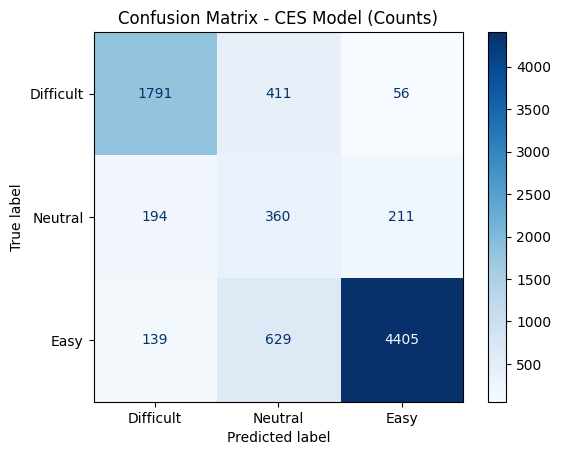

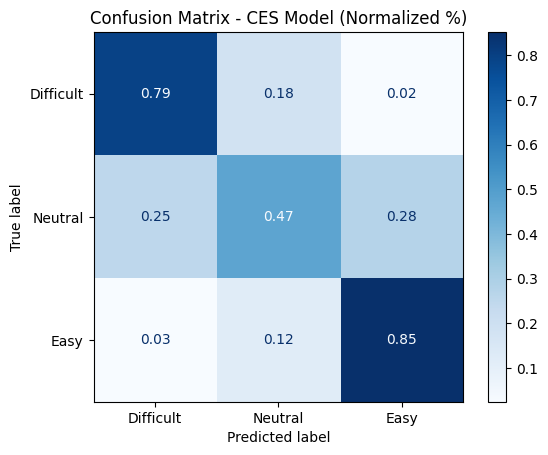

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix (Counts)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Difficult", "Neutral", "Easy"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - CES Model (Counts)")
plt.savefig("/content/drive/MyDrive/P1/CES_confusion_matrix_counts.png", dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix (Normalized)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Difficult", "Neutral", "Easy"])
disp.plot(cmap='Blues', values_format=".2f")
plt.title("Confusion Matrix - CES Model (Normalized %)")
plt.savefig("/content/drive/MyDrive/P1/CES_confusion_matrix_normalized.png", dpi=300, bbox_inches='tight')
plt.show()
